## Examen Practico - Segundo Parcial

# PROCESAMIENTO DE IMAGEN 1 (histo_1.jpg)

### 0) Cargar la primera imagen histológica

Dimensiones de la imagen: (1024, 1024, 3)
Rango de valores: [0.000, 1.000]


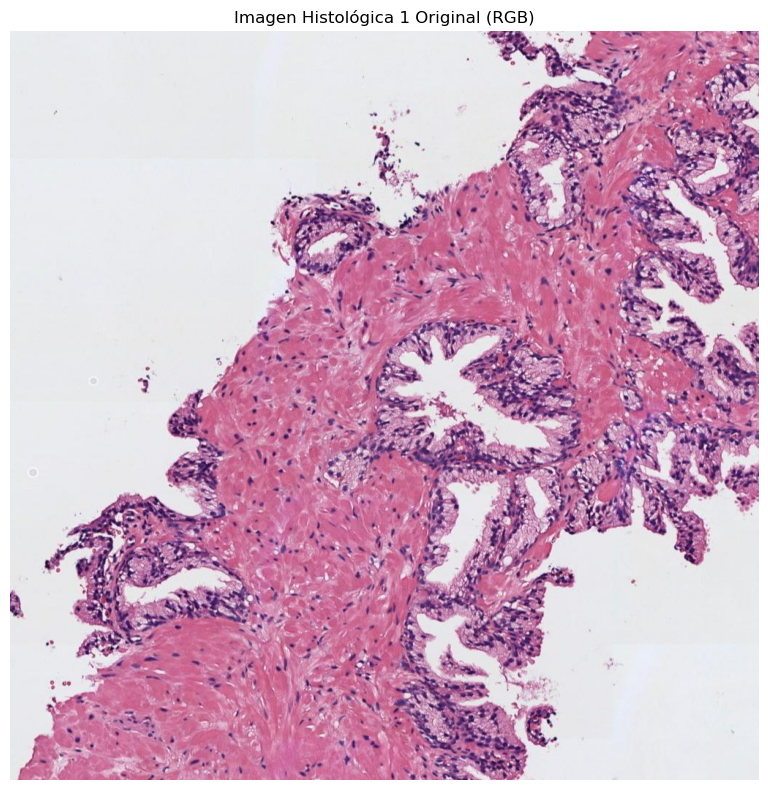

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import io, color, filters, morphology, measure
from scipy import ndimage
import cv2
from PIL import Image
import pandas as pd
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Cargar la imagen en formato RGB
img = io.imread('histo_1.jpg')

# Normalizar la imagen al rango [0, 1]
if img.dtype == np.uint8:
    img_normalized = img.astype(np.float32) / 255.0
else:
    img_normalized = img.astype(np.float32)

print(f"Dimensiones de la imagen: {img_normalized.shape}")
print(f"Rango de valores: [{img_normalized.min():.3f}, {img_normalized.max():.3f}]")

# Visualizar la imagen
plt.figure(figsize=(10, 8))
plt.imshow(img_normalized)
plt.title('Imagen Histológica 1 Original (RGB)')
plt.axis('off')
plt.tight_layout()
plt.show()

### 1) Transformación de color a CMYK

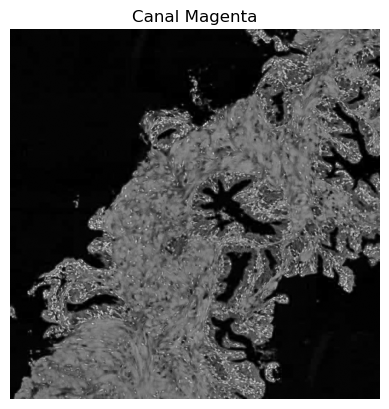

Rango: [0.000, 1.000]


In [3]:
# Convertir de RGB a CMYK (solo lo necesario)
def rgb_to_cmyk(img_rgb):
    img_rgb = np.clip(img_rgb, 0, 1)
    K = 1 - np.max(img_rgb, axis=2)
    M = (1 - img_rgb[:, :, 1] - K) / (1 - K + 1e-8)
    return M  # Solo devolvemos magenta

# Obtener canal magenta
img_magenta = rgb_to_cmyk(img_normalized)

# Mostrar solo magenta
plt.imshow(img_magenta, cmap='gray')
plt.title('Canal Magenta')
plt.axis('off')
plt.show()

# Opcional: ver rango
print(f"Rango: [{img_magenta.min():.3f}, {img_magenta.max():.3f}]")

### 2) Umbralización

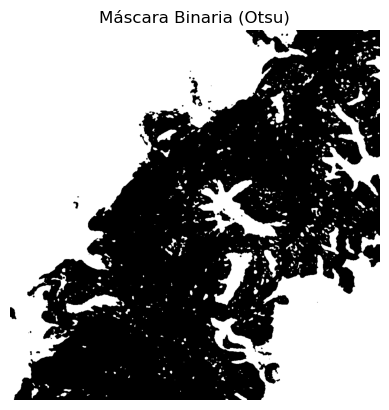

In [5]:
# Preprocesamiento
img_magenta_uint8 = (img_magenta * 255).astype(np.uint8)
img_blurred = cv2.GaussianBlur(img_magenta_uint8, (5, 5), 0)

# Umbralización de Otsu
_, binary_mask = cv2.threshold(
    img_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Convertir a binario (0 y 1)
binary_mask = (binary_mask > 0).astype(np.uint8)

# Mostrar solo la máscara
plt.imshow(binary_mask, cmap='gray')
plt.title('Máscara Binaria (Otsu)')
plt.axis('off')
plt.show()

### 3) Limpieza de artefactos

Píxeles después de limpiar artefactos: 482294
Píxeles eliminados: 16146


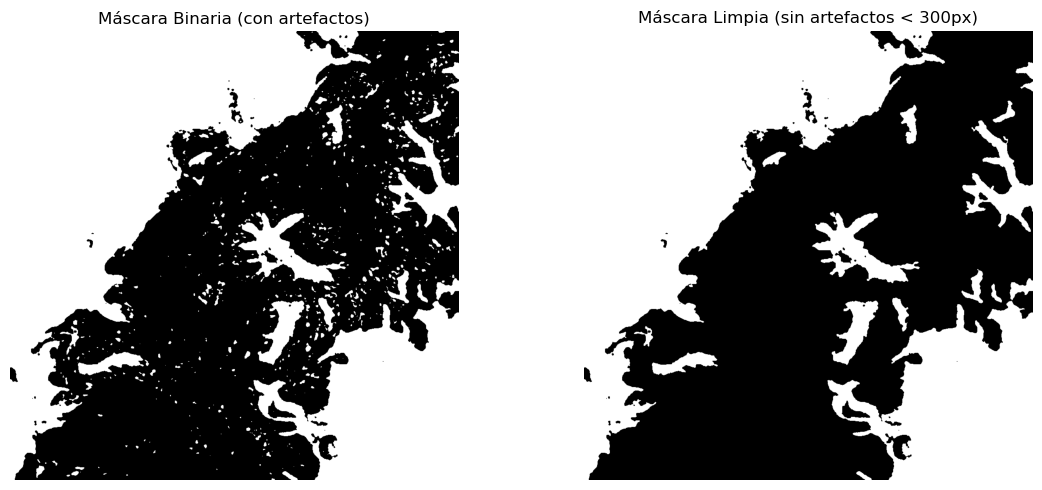

In [6]:
# Eliminar objetos pequeños (artefactos de lumen menores a 300 píxeles)
cleaned_mask = morphology.remove_small_objects(binary_mask.astype(bool), min_size=300)
cleaned_mask = cleaned_mask.astype(np.uint8)

print(f"Píxeles después de limpiar artefactos: {np.sum(cleaned_mask > 0)}")
print(f"Píxeles eliminados: {np.sum(binary_mask) - np.sum(cleaned_mask)}")

# Visualizar la máscara resultante
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(binary_mask, cmap='gray')
plt.title('Máscara Binaria (con artefactos)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cleaned_mask, cmap='gray')
plt.title('Máscara Limpia (sin artefactos < 300px)')
plt.axis('off')
plt.tight_layout()
plt.show()

### 4) Region Growing

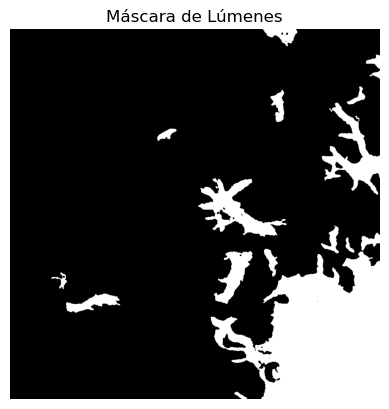

In [8]:
# Componentes conectados
h, w = cleaned_mask.shape

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    cleaned_mask, connectivity=8
)

# Filtrado por área
min_area = 100
max_area = (h * w) * 0.3

lumen_mask = np.zeros_like(cleaned_mask)

for i in range(1, num_labels):  # 0 = fondo
    area = stats[i, cv2.CC_STAT_AREA]
    if min_area < area < max_area:
        lumen_mask[labels == i] = 255

# Mostrar solo la máscara de lúmenes
plt.imshow(lumen_mask, cmap='gray')
plt.title('Máscara de Lúmenes')
plt.axis('off')
plt.show()

# Guardar para uso posterior
rg_mask = lumen_mask.copy()

### 5) Relleno de lúmenes

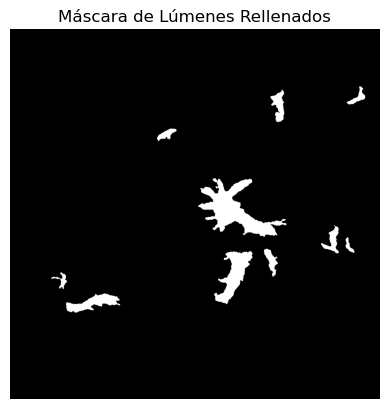

In [10]:
from scipy import ndimage
import cv2
import numpy as np
import matplotlib.pyplot as plt

filled_mask = np.zeros_like(rg_mask)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    rg_mask, connectivity=8
)

h, w = rg_mask.shape

for i in range(1, num_labels):  # 0 = fondo
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    comp_w = stats[i, cv2.CC_STAT_WIDTH]
    comp_h = stats[i, cv2.CC_STAT_HEIGHT]
    
    toca_borde = (x <= 0 or y <= 0 or 
                  x + comp_w >= w or 
                  y + comp_h >= h)
    
    if not toca_borde:
        componente = (labels == i).astype(np.uint8)
        componente_filled = ndimage.binary_fill_holes(componente).astype(np.uint8)
        filled_mask = cv2.bitwise_or(filled_mask, componente_filled * 255)

# Mostrar solo la máscara final
plt.imshow(filled_mask, cmap='gray')
plt.title('Máscara de Lúmenes Rellenados')
plt.axis('off')
plt.show()

### 6) Detección de contornos

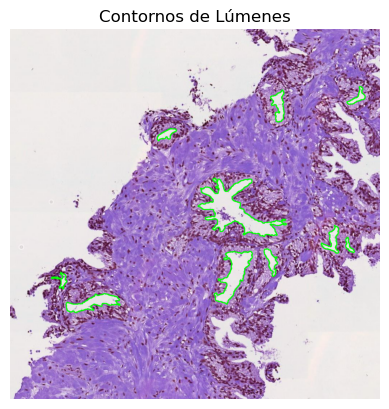

In [12]:
# Convertir a uint8
img_uint8 = (img_normalized * 255).astype(np.uint8)

# Encontrar contornos
contours, _ = cv2.findContours(
    filled_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
)

# Dibujar contornos en verde
img_with_contours = img_uint8.copy()
cv2.drawContours(img_with_contours, contours, -1, (0, 255, 0), 2)

# Mostrar solo la imagen final
plt.imshow(cv2.cvtColor(img_with_contours, cv2.COLOR_BGR2RGB))
plt.title('Contornos de Lúmenes')
plt.axis('off')
plt.show()

### 7) Extracción del lumen más grande

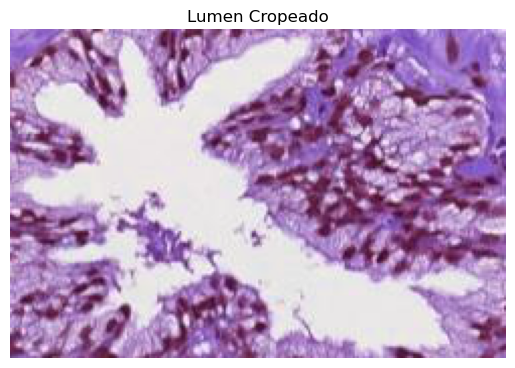

In [14]:
# Filtrar contornos válidos
h_img, w_img = filled_mask.shape
min_area = 100
max_area_limit = (h_img * w_img) * 0.3

contours_filtrados = [
    c for c in contours
    if min_area < cv2.contourArea(c) < max_area_limit
]

# Encontrar el contorno de mayor área
max_contour = max(contours_filtrados, key=cv2.contourArea, default=None)

# Obtener y mostrar solo el crop
if max_contour is not None:
    x, y, w, h = cv2.boundingRect(max_contour)
    lumen_crop = img_uint8[y:y+h, x:x+w].copy()

    plt.imshow(cv2.cvtColor(lumen_crop, cv2.COLOR_BGR2RGB))
    plt.title('Lumen Cropeado')
    plt.axis('off')
    plt.show()

### 8) Extracción de 13 características geométricas

In [15]:
# Verificar que filled_mask tiene contenido
print(f"Píxeles en filled_mask: {np.sum(filled_mask > 0)}")

# Encontrar el contorno más grande
contours, _ = cv2.findContours(filled_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Contornos encontrados: {len(contours)}")

if len(contours) == 0:
    print("ERROR: No se encontraron contornos en filled_mask")
else:
    # Seleccionar el contorno más grande por área
    max_contour = max(contours, key=cv2.contourArea)
    print(f"Área del contorno más grande: {cv2.contourArea(max_contour)}")

    h, w = filled_mask.shape
    
    # Extraer la máscara binaria del lumen más grande
    lumen_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(lumen_mask, [max_contour], 0, 1, -1)
    
    # Verificar que la máscara tiene contenido
    print(f"Píxeles en lumen_mask: {np.sum(lumen_mask)}")
    
    # Obtener propiedades
    labeled = measure.label(lumen_mask)
    regions = measure.regionprops(labeled)
    
    if len(regions) == 0:
        print("ERROR: regionprops no encontró regiones")
    else:
        props = regions[0]
        print("Props obtenidas correctamente ✓")
        
        # Calcular las 13 características
        features = {}
        features['Area'] = round(props.area, 4)
        features['Area_bbox'] = round(props.bbox_area, 4)
        features['Area_convexa'] = round(props.convex_area, 4)
        features['Excentricidad'] = round(props.eccentricity, 4)
        features['Diametro_equivalente'] = round(props.equivalent_diameter, 4)
        features['Extension'] = round(props.extent, 4)

        feret_diameter = 0
        for i in range(len(max_contour)):
            for j in range(i+1, len(max_contour)):
                dist = np.linalg.norm(max_contour[i] - max_contour[j])
                if dist > feret_diameter:
                    feret_diameter = dist
        features['Diametro_Feret'] = round(float(feret_diameter), 4)

        features['Longitud_eje_mayor'] = round(props.major_axis_length, 4)
        features['Longitud_eje_menor'] = round(props.minor_axis_length, 4)
        features['Orientacion'] = round(props.orientation, 4)

        contour_length = cv2.arcLength(max_contour, True)
        features['Perimetro'] = round(float(contour_length), 4)
        features['Solidez'] = round(props.solidity, 4)

        compactness = (4 * np.pi * props.area) / (contour_length ** 2) if contour_length > 0 else 0
        features['Compacidad'] = round(float(compactness), 4)

        # Mostrar resultados
        print("=" * 60)
        print("CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN MÁS GRANDE - IMAGEN 1")
        print("=" * 60)
        for i, (name, value) in enumerate(features.items(), 1):
            print(f"{i:2d}. {name:25s}: {value:12.4f}")
        print("=" * 60)

        features_2 = features.copy()
        df_features_2 = pd.DataFrame(list(features_2.items()), columns=['Característica', 'Valor'])
        print("\nTabla de características (Imagen 1):")
        print(df_features_2.to_string(index=False))

Píxeles en filled_mask: 31756
Contornos encontrados: 10
Área del contorno más grande: 13542.0
Píxeles en lumen_mask: 14075
Props obtenidas correctamente ✓
CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN MÁS GRANDE - IMAGEN 1
 1. Area                     :   14075.0000
 2. Area_bbox                :   40098.0000
 3. Area_convexa             :   29283.0000
 4. Excentricidad            :       0.8478
 5. Diametro_equivalente     :     133.8688
 6. Extension                :       0.3510
 7. Diametro_Feret           :     258.1550
 8. Longitud_eje_mayor       :     238.6358
 9. Longitud_eje_menor       :     126.5495
10. Orientacion              :       1.0058
11. Perimetro                :    1246.2540
12. Solidez                  :       0.4807
13. Compacidad               :       0.1139

Tabla de características (Imagen 1):
      Característica      Valor
                Area 14075.0000
           Area_bbox 40098.0000
        Area_convexa 29283.0000
       Excentricidad     0.8478
Diametro_equiva

---

# PROCESAMIENTO DE IMAGEN 2 (histo_2.jpg)

### 0) Cargar la segunda imagen histológica

Dimensiones de la imagen 2: (1024, 1024, 3)
Rango de valores: [0.114, 1.000]


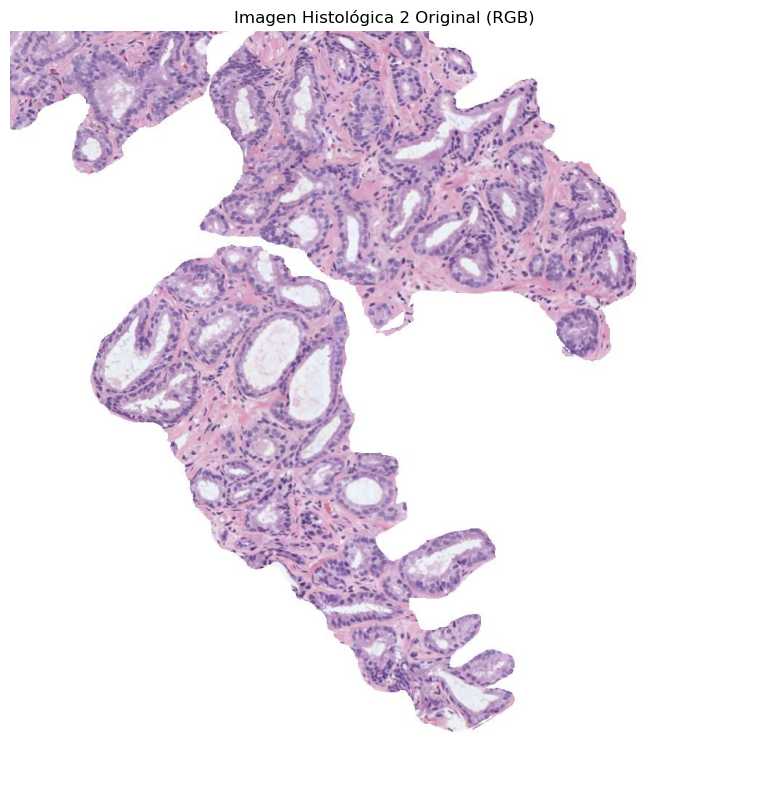

In [18]:
# Cargar la segunda imagen en formato RGB
img_2 = io.imread('histo_2.jpg')

# Normalizar la imagen al rango [0, 1]
if img_2.dtype == np.uint8:
    img_normalized_2 = img_2.astype(np.float32) / 255.0
else:
    img_normalized_2 = img_2.astype(np.float32)

print(f"Dimensiones de la imagen 2: {img_normalized_2.shape}")
print(f"Rango de valores: [{img_normalized_2.min():.3f}, {img_normalized_2.max():.3f}]")

# Visualizar la imagen
plt.figure(figsize=(10, 8))
plt.imshow(img_normalized_2)
plt.title('Imagen Histológica 2 Original (RGB)')
plt.axis('off')
plt.tight_layout()
plt.show()

### 1) Transformación de color a CMYK

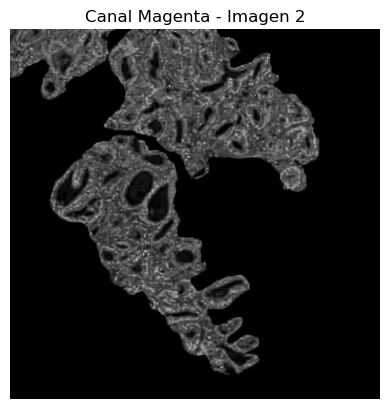

In [22]:
# Obtener directamente el canal magenta
img_magenta_2 = rgb_to_cmyk(img_normalized_2)

# Mostrar
plt.imshow(img_magenta_2, cmap='gray')
plt.title('Canal Magenta - Imagen 2')
plt.axis('off')
plt.show()

### 2) Umbralización

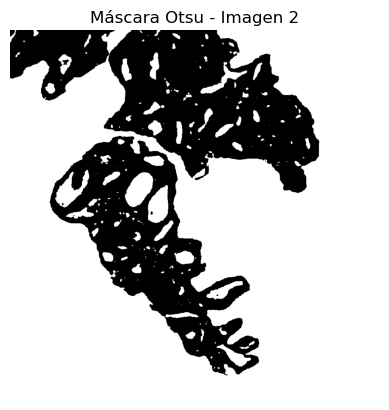

In [24]:
# Preprocesamiento
img_magenta_uint8_2 = (img_magenta_2 * 255).astype(np.uint8)
img_blurred_2 = cv2.GaussianBlur(img_magenta_uint8_2, (5, 5), 0)

# Otsu
_, binary_mask_2 = cv2.threshold(
    img_blurred_2, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Convertir a binario (0 y 1)
binary_mask_2 = (binary_mask_2 > 0).astype(np.uint8)

# Mostrar solo la máscara
plt.imshow(binary_mask_2, cmap='gray')
plt.title('Máscara Otsu - Imagen 2')
plt.axis('off')
plt.show()

### 3) Limpieza de artefactos

Píxeles después de limpiar artefactos (imagen 2): 729371
Píxeles eliminados: 7567


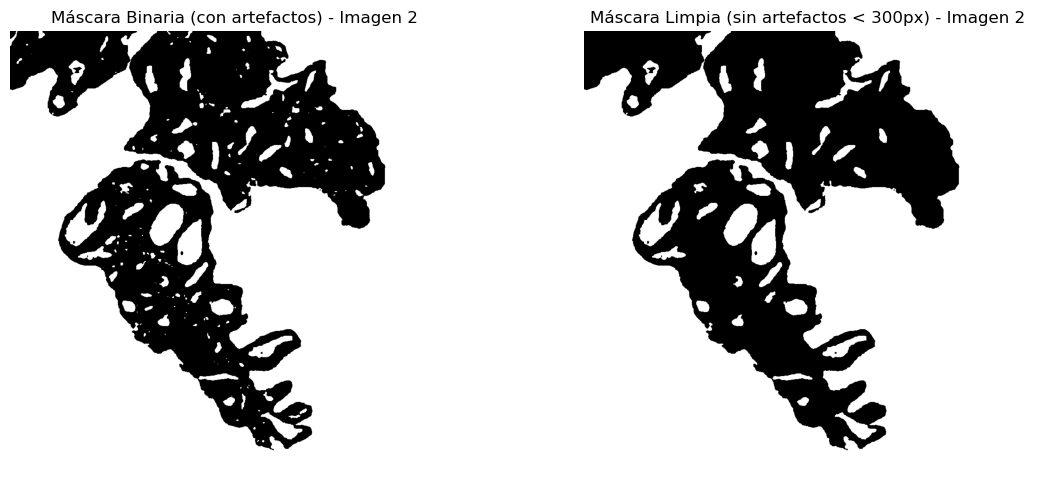

In [25]:
# Eliminar objetos pequeños (artefactos de lumen menores a 300 píxeles)
cleaned_mask_2 = morphology.remove_small_objects(binary_mask_2.astype(bool), min_size=300)
cleaned_mask_2 = cleaned_mask_2.astype(np.uint8)

print(f"Píxeles después de limpiar artefactos (imagen 2): {np.sum(cleaned_mask_2 > 0)}")
print(f"Píxeles eliminados: {np.sum(binary_mask_2) - np.sum(cleaned_mask_2)}")

# Visualizar la máscara resultante
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(binary_mask_2, cmap='gray')
plt.title('Máscara Binaria (con artefactos) - Imagen 2')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cleaned_mask_2, cmap='gray')
plt.title('Máscara Limpia (sin artefactos < 300px) - Imagen 2')
plt.axis('off')
plt.tight_layout()
plt.show()

### 4) Region Growing

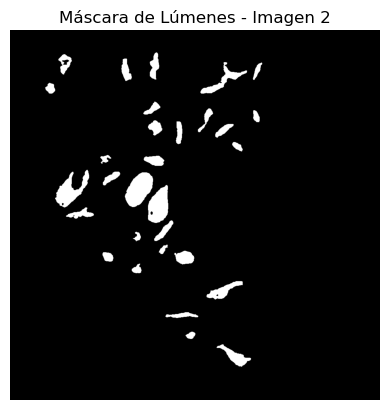

In [27]:
# Componentes conectados
h2, w2 = cleaned_mask_2.shape

num_labels_2, labels_2, stats_2, _ = cv2.connectedComponentsWithStats(
    cleaned_mask_2, connectivity=8
)

min_area = 100
max_area = (h2 * w2) * 0.3

rg_mask_2 = np.zeros_like(cleaned_mask_2)

for i in range(1, num_labels_2):
    area = stats_2[i, cv2.CC_STAT_AREA]
    if min_area < area < max_area:
        rg_mask_2[labels_2 == i] = 255

# Mostrar solo la máscara
plt.imshow(rg_mask_2, cmap='gray')
plt.title('Máscara de Lúmenes - Imagen 2')
plt.axis('off')
plt.show()

### 5) Relleno de lúmenes

Lúmenes procesados imagen 2: 30
Píxeles después de rellenar (imagen 2): 38105


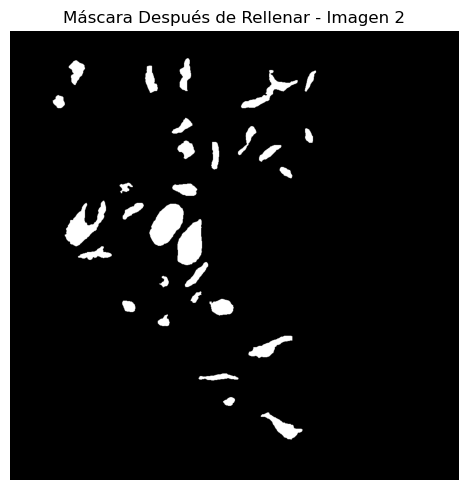

In [29]:
filled_mask_2 = np.zeros_like(rg_mask_2)
num_labels_2, labels_2, stats_2, _ = cv2.connectedComponentsWithStats(
    rg_mask_2, connectivity=8
)
for i in range(1, num_labels_2):
    componente = (labels_2 == i).astype(np.uint8)
    componente_filled = ndimage.binary_fill_holes(componente).astype(np.uint8)
    filled_mask_2 = cv2.bitwise_or(filled_mask_2, componente_filled * 255)
print(f"Lúmenes procesados imagen 2: {num_labels_2 - 1}")
print(f"Píxeles después de rellenar (imagen 2): {np.sum(filled_mask_2 > 0)}")

plt.figure(figsize=(6, 5))
plt.imshow(filled_mask_2, cmap='gray')
plt.title('Máscara Después de Rellenar - Imagen 2')
plt.axis('off')
plt.tight_layout()
plt.show()

### 6) Detección de contornos

Número de lúmenes detectados (imagen 2): 30


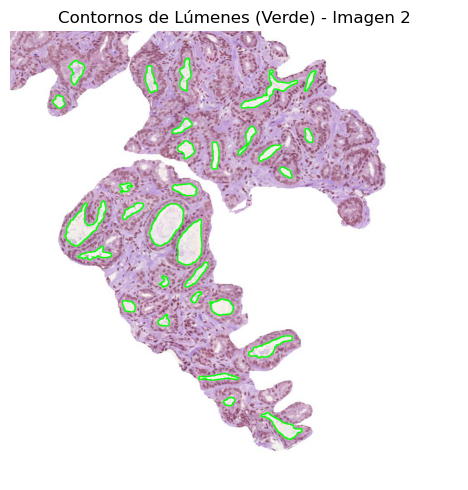

In [31]:
img_uint8_2 = (img_normalized_2 * 255).astype(np.uint8)
contours_2, hierarchy_2 = cv2.findContours(filled_mask_2, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
img_with_contours_2 = img_uint8_2.copy()
cv2.drawContours(img_with_contours_2, contours_2, -1, (0, 255, 0), 2)
print(f"Número de lúmenes detectados (imagen 2): {len(contours_2)}")

plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(img_with_contours_2, cv2.COLOR_BGR2RGB))
plt.title('Contornos de Lúmenes (Verde) - Imagen 2')
plt.axis('off')
plt.tight_layout()
plt.show()

### 7) Extracción del lumen más grande

Área del lumen más grande (imagen 2): 4762.50 píxeles
Dimensiones del crop (imagen 2): (96, 78, 3)
Coordenadas del lumen (x, y, w, h): (318, 394, 78, 96)


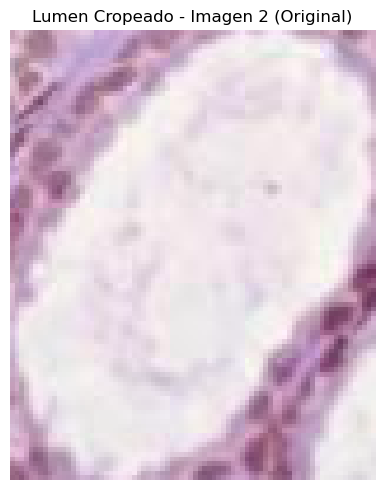

In [33]:
max_area_2 = 0
max_contour_2 = None
max_index_2 = -1
for i, contour in enumerate(contours_2):
    area = cv2.contourArea(contour)
    if area > max_area_2:
        max_area_2 = area
        max_contour_2 = contour
        max_index_2 = i
print(f"Área del lumen más grande (imagen 2): {max_area_2:.2f} píxeles")

if max_contour_2 is not None:
    x_2, y_2, w_2, h_2 = cv2.boundingRect(max_contour_2)
    lumen_crop_2 = img_uint8_2[y_2:y_2+h_2, x_2:x_2+w_2].copy()
    print(f"Dimensiones del crop (imagen 2): {lumen_crop_2.shape}")
    print(f"Coordenadas del lumen (x, y, w, h): ({x_2}, {y_2}, {w_2}, {h_2})")

    plt.figure(figsize=(6, 5))
    plt.imshow(cv2.cvtColor(lumen_crop_2, cv2.COLOR_BGR2RGB))
    plt.title('Lumen Cropeado - Imagen 2 (Original)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### 8) Extracción de 13 características geométricas

In [34]:
# ── PASO COMPLETO IMAGEN 2 ──────────────────────────────────

# 1) Obtener dimensiones y contornos
h_2, w_2 = filled_mask_2.shape

contours_2, _ = cv2.findContours(filled_mask_2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Contornos encontrados imagen 2: {len(contours_2)}")

if len(contours_2) == 0:
    print("ERROR: No hay contornos en filled_mask_2")
else:
    # 2) Seleccionar el contorno más grande
    max_contour_2 = max(contours_2, key=cv2.contourArea)
    print(f"Área contorno más grande: {cv2.contourArea(max_contour_2)}")

    # 3) Extraer máscara binaria del lumen más grande
    lumen_mask_2 = np.zeros((h_2, w_2), dtype=np.uint8)
    cv2.drawContours(lumen_mask_2, [max_contour_2], 0, 1, -1)

    # 4) Obtener propiedades con regionprops
    labeled_2 = measure.label(lumen_mask_2)
    regions_2 = measure.regionprops(labeled_2)

    if len(regions_2) == 0:
        print("ERROR: regionprops no encontró regiones")
    else:
        props_2 = regions_2[0]

        # 5) Calcular las 13 características
        features_2 = {}

        features_2['Area']                 = round(props_2.area, 4)
        features_2['Area_bbox']            = round(props_2.bbox_area, 4)
        features_2['Area_convexa']         = round(props_2.convex_area, 4)
        features_2['Excentricidad']        = round(props_2.eccentricity, 4)
        features_2['Diametro_equivalente'] = round(props_2.equivalent_diameter, 4)
        features_2['Extension']            = round(props_2.extent, 4)

        feret_diameter_2 = 0
        for i in range(len(max_contour_2)):
            for j in range(i+1, len(max_contour_2)):
                dist = np.linalg.norm(max_contour_2[i] - max_contour_2[j])
                if dist > feret_diameter_2:
                    feret_diameter_2 = dist
        features_2['Diametro_Feret']       = round(float(feret_diameter_2), 4)

        features_2['Longitud_eje_mayor']   = round(props_2.major_axis_length, 4)
        features_2['Longitud_eje_menor']   = round(props_2.minor_axis_length, 4)
        features_2['Orientacion']          = round(props_2.orientation, 4)

        contour_length_2 = cv2.arcLength(max_contour_2, True)
        features_2['Perimetro']            = round(float(contour_length_2), 4)
        features_2['Solidez']              = round(props_2.solidity, 4)

        compactness_2 = (4 * np.pi * props_2.area) / (contour_length_2 ** 2) if contour_length_2 > 0 else 0
        features_2['Compacidad']           = round(float(compactness_2), 4)

        # 6) Mostrar resultados
        print("=" * 60)
        print("CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN MÁS GRANDE - IMAGEN 2")
        print("=" * 60)
        for i, (name, value) in enumerate(features_2.items(), 1):
            print(f"{i:2d}. {name:25s}: {value:12.4f}")
        print("=" * 60)

        df_features_2 = pd.DataFrame(list(features_2.items()), columns=['Característica', 'Valor'])
        print("\nTabla de características (Imagen 2):")
        print(df_features_2.to_string(index=False))

Contornos encontrados imagen 2: 30
Área contorno más grande: 4762.5
CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN MÁS GRANDE - IMAGEN 2
 1. Area                     :    4881.0000
 2. Area_bbox                :    7488.0000
 3. Area_convexa             :    5013.0000
 4. Excentricidad            :       0.8350
 5. Diametro_equivalente     :      78.8333
 6. Extension                :       0.6518
 7. Diametro_Feret           :     104.4462
 8. Longitud_eje_mayor       :     106.5053
 9. Longitud_eje_menor       :      58.5976
10. Orientacion              :      -0.5613
11. Perimetro                :     280.9777
12. Solidez                  :       0.9737
13. Compacidad               :       0.7769

Tabla de características (Imagen 2):
      Característica     Valor
                Area 4881.0000
           Area_bbox 7488.0000
        Area_convexa 5013.0000
       Excentricidad    0.8350
Diametro_equivalente   78.8333
           Extension    0.6518
      Diametro_Feret  104.4462
  Longitud_eje

---

# ANÁLISIS COMPARATIVO ENTRE AMBAS IMÁGENES

In [35]:
# Crear una tabla comparativa de características
comparison_data = []
for key in features.keys():
    comparison_data.append({
        'Característica': key,
        'Imagen 1': features[key],
        'Imagen 2': features_2[key],
        'Diferencia': round(features[key] - features_2[key], 4),
        'Diferencia %': round((abs(features[key] - features_2[key]) / ((features[key] + features_2[key])/2)) * 100, 2)
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("TABLA COMPARATIVA DE CARACTERÍSTICAS ENTRE AMBAS IMÁGENES")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

print("\n Análisis comparativo completado")


TABLA COMPARATIVA DE CARACTERÍSTICAS ENTRE AMBAS IMÁGENES
      Característica   Imagen 1  Imagen 2  Diferencia  Diferencia %
                Area 14075.0000 4881.0000   9194.0000         97.00
           Area_bbox 40098.0000 7488.0000  32610.0000        137.06
        Area_convexa 29283.0000 5013.0000  24270.0000        141.53
       Excentricidad     0.8478    0.8350      0.0128          1.52
Diametro_equivalente   133.8688   78.8333     55.0355         51.75
           Extension     0.3510    0.6518     -0.3008         59.99
      Diametro_Feret   258.1550  104.4462    153.7088         84.78
  Longitud_eje_mayor   238.6358  106.5053    132.1305         76.57
  Longitud_eje_menor   126.5495   58.5976     67.9519         73.40
         Orientacion     1.0058   -0.5613      1.5671        705.11
           Perimetro  1246.2540  280.9777    965.2763        126.41
             Solidez     0.4807    0.9737     -0.4930         67.79
          Compacidad     0.1139    0.7769     -0.6630    

Github: https://github.com/Steven-tec/machine-learning-2.git